# Titanic Logistic Regression Survival Prediction

## Environment Setup

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
import seaborn as sns

## Config

In [2]:
RANDOM_STATE = 2
LEARNING_RATE = 0.005
EPOCHS = 100
BATCH_SIZE = 32
VAL_SPLIT = 0.2
TEST_SPLIT = 0.125

## Dataset Loading & EDA

In [3]:
raw_df = pd.read_csv('data/train.csv')
raw_df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
raw_df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    str    
 4   Sex          891 non-null    str    
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    str    
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    str    
 11  Embarked     889 non-null    str    
dtypes: float64(2), int64(5), str(5)
memory usage: 118.9 KB


In [5]:
raw_df.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.000000,891.000000,891.000000,714.000000,891.000000,891.000000,891.000000
mean,446.000000,0.383838,2.308642,29.699118,0.523008,0.381594,32.204208
std,257.353842,0.486592,0.836071,14.526497,1.102743,0.806057,49.693429
min,1.000000,0.000000,1.000000,0.420000,0.000000,0.000000,0.000000
25%,223.500000,0.000000,2.000000,20.125000,0.000000,0.000000,7.910400
50%,446.000000,0.000000,3.000000,28.000000,0.000000,0.000000,14.454200
75%,668.500000,1.000000,3.000000,38.000000,1.000000,0.000000,31.000000
max,891.000000,1.000000,3.000000,80.000000,8.000000,6.000000,512.329200


In [6]:
print(raw_df['Sex'].unique())
print(raw_df['Cabin'].unique())
print(raw_df['Embarked'].unique())

<ArrowStringArray>
['male', 'female']
Length: 2, dtype: str
<ArrowStringArray>
[          nan,         'C85',        'C123',         'E46',          'G6',
        'C103',         'D56',          'A6', 'C23 C25 C27',         'B78',
 ...
        'B102',         'B69',         'E49',         'C47',         'D28',
         'E17',         'A24',         'C50',         'B42',        'C148']
Length: 148, dtype: str
<ArrowStringArray>
['S', 'C', 'Q', nan]
Length: 4, dtype: str


In [7]:
for i in range(1, 4):
    for embark in ['C', 'S', 'Q']:
        print(f"Pclass {i} with {embark}: {raw_df[(raw_df['Pclass'] == i) & (raw_df['Embarked'] == embark)].shape[0]}")

Pclass 1 with C: 85
Pclass 1 with S: 127
Pclass 1 with Q: 2
Pclass 2 with C: 17
Pclass 2 with S: 164
Pclass 2 with Q: 3
Pclass 3 with C: 66
Pclass 3 with S: 353
Pclass 3 with Q: 72


## Data Processing & Feature Engineering

In [8]:
df = raw_df.drop(columns=['PassengerId', 'Cabin', 'Name', 'Ticket'])

df['Embarked'] = df['Embarked'].fillna('S')
df = pd.get_dummies(df, columns = ['Embarked'], dtype = int)

df['Sex'] = df['Sex'].apply(lambda x: 1 if x == "male" else 0)
df['Family'] = df['SibSp'] + df['Parch'] 
df['Age'] = df['Age'].fillna(df['Age'].median())

df['Fare'] = df['Fare'].fillna(df.groupby('Pclass')['Fare'].transform('mean'))
df['Fare'] = np.log1p(df['Fare'])

In [9]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 11 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Survived    891 non-null    int64  
 1   Pclass      891 non-null    int64  
 2   Sex         891 non-null    int64  
 3   Age         891 non-null    float64
 4   SibSp       891 non-null    int64  
 5   Parch       891 non-null    int64  
 6   Fare        891 non-null    float64
 7   Embarked_C  891 non-null    int64  
 8   Embarked_Q  891 non-null    int64  
 9   Embarked_S  891 non-null    int64  
 10  Family      891 non-null    int64  
dtypes: float64(2), int64(9)
memory usage: 76.7 KB


<Axes: >

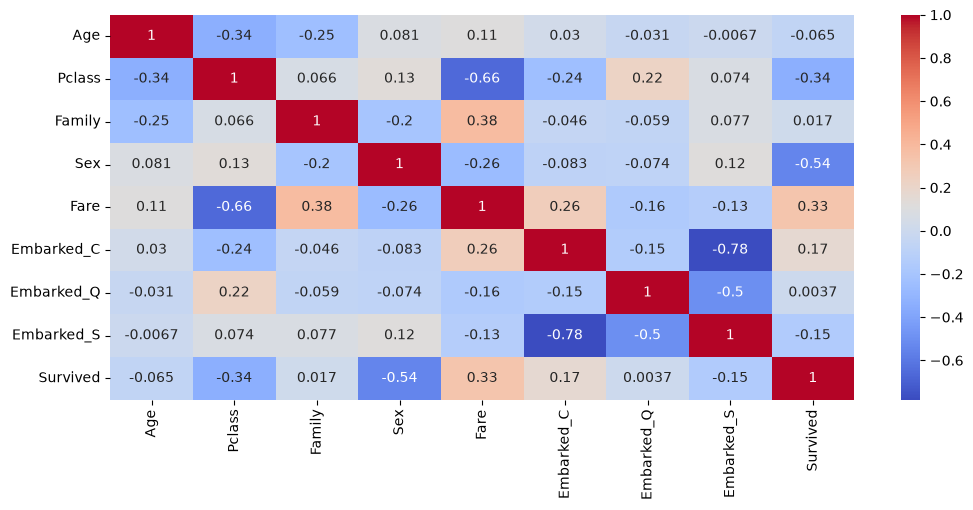

In [10]:
corr = df[['Age', 'Pclass', 'Family', 'Sex', 'Fare', 'Embarked_C', 'Embarked_Q', 'Embarked_S', 'Survived']].corr()

plt.figure(figsize = (12, 5))

sns.heatmap(
    corr,
    annot = True,
    cmap = 'coolwarm',
    cbar = True
)

## Data Preparation

In [11]:
data = df.drop(columns = ['SibSp', 'Parch'])
X = data.drop(columns = ['Survived']).to_numpy()
X = np.hstack([np.ones((X.shape[0], 1)), X])
y = data['Survived'].to_numpy()

X_trainval, X_val, y_trainval, y_val = train_test_split(X, y, test_size=VAL_SPLIT, stratify=y, random_state=RANDOM_STATE)
X_train, X_test, y_train, y_test = train_test_split(X_trainval, y_trainval, test_size=TEST_SPLIT, stratify=y_trainval, random_state=RANDOM_STATE)


In [12]:
print(f"Train size: {len(X_train) / len(X) * 100:.1f}%")
print(f"Val size:   {len(X_val) / len(X) * 100:.1f}%")
print(f"Test size:  {len(X_test) / len(X) * 100:.1f}%")

Train size: 69.9%
Val size:   20.1%
Test size:  10.0%


## Normalization

In [13]:
scaler = StandardScaler()

X_train[:, 1:] = scaler.fit_transform(X_train[:, 1:])
X_val[:, 1:] = scaler.transform(X_val[:, 1:])
X_test[:, 1:] = scaler.transform(X_test[:, 1:])

## Helper Functions

In [14]:
def sigmoid(z):
    return 1 / (1 + np.exp(-z))

In [15]:
def predict(X, theta):

    logits = X @ theta

    y_hat = sigmoid(logits)

    return y_hat

In [16]:
def compute_loss(y_pred, y_true):

    y_pred = np.clip(y_pred, 1e-7, 1 - 1e-7)

    loss = np.mean(-y_true * np.log(y_pred) - (1 - y_true) * np.log(1 - y_pred))

    return loss

In [17]:
def compute_gradient(X, y_true, y_pred):

    gradient = (X.T @ (y_pred - y_true)) / len(X) 

    return gradient

In [18]:
def update_theta(theta, gradient, lr):
    return theta - lr * gradient

In [19]:
def compute_accuracy(y_pred, y_true):

    preds = np.round(y_pred, 0)
    correct = np.sum(y_true == preds)

    accuracy = correct / y_true.shape[0]

    return accuracy

## Training Loop

In [ ]:
theta = np.zeros(X_train.shape[1])
train_losses, val_losses, train_accs, val_accs = [], [], [], []



for epoch in range(EPOCHS):

    for start in range(0, len(X_train), BATCH_SIZE):

        X_batch = X_train[start : start+BATCH_SIZE]
        y_batch = y_train[start : start+BATCH_SIZE]

        y_hat_batch = predict(X_batch, theta)
        grad = compute_gradient(X_batch, y_batch, y_hat_batch)
        theta = update_theta(theta, grad, LEARNING_RATE)
    
    train_loss = compute_loss(predict(X_train, theta), y_train)
    val_loss = compute_loss(predict(X_val, theta), y_val)
    train_acc = compute_accuracy(predict(X_train, theta), y_train)
    val_acc = compute_accuracy(predict(X_val, theta), y_val)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)


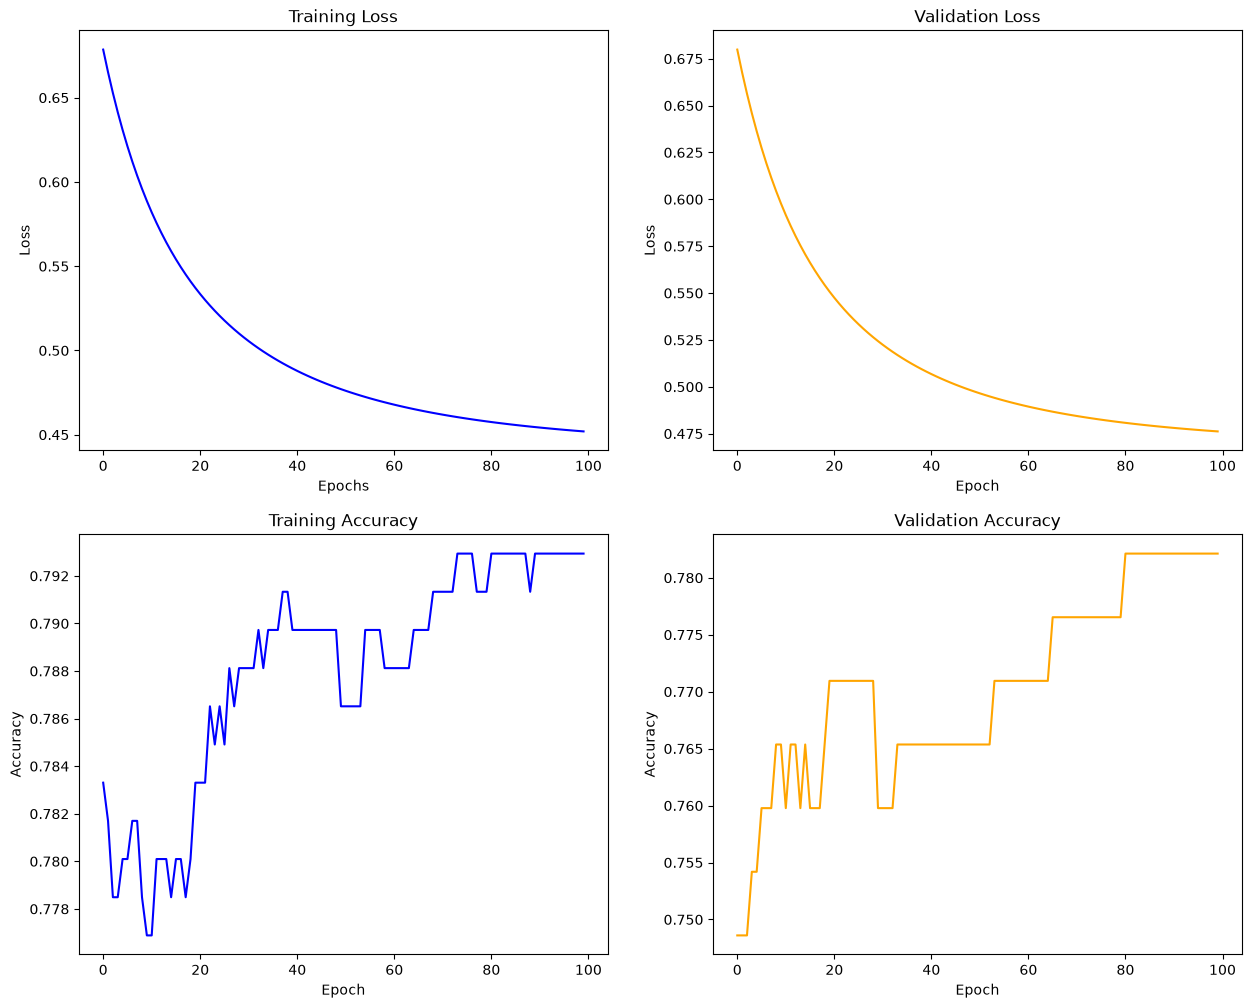

In [21]:
fig, (ax1, ax2) = plt.subplots(2, 2, figsize=(15, 12))

ax1[0].plot(train_losses, color='blue')
ax1[0].set_title('Training Loss')
ax1[0].set_xlabel('Epochs')
ax1[0].set_ylabel('Loss')

ax1[1].plot(val_losses, color='orange')
ax1[1].set_title('Validation Loss')
ax1[1].set_xlabel('Epoch')
ax1[1].set_ylabel('Loss')

ax2[0].plot(train_accs, color='blue')
ax2[0].set_title('Training Accuracy')
ax2[0].set_xlabel('Epoch')
ax2[0].set_ylabel('Accuracy')

ax2[1].plot(val_accs, color='orange')
ax2[1].set_title('Validation Accuracy')
ax2[1].set_xlabel('Epoch')
ax2[1].set_ylabel('Accuracy')


plt.show()
